# 01 — Microstructure EDA

Exploratory analysis of the simulated Level-2 order-book snapshots used by `liquidity-anomaly-detector`.

Goals:
1. Load raw snapshots and run them through the same `DataPipeline` feature engineering used at train time.
2. Visualize the **phase space of spread vs. depth**, distinguishing pre-shock windows from normal regimes.
3. Empirically confirm that fractional differencing achieves stationarity at a much lower order `d` than integer differencing (`d=1`), i.e. it preserves more memory.

Run `python main.py simulate --out data/raw/lob_snapshots.csv` from the project root first if the raw CSV doesn't exist yet.

In [1]:
import sys
sys.path.insert(0, "..")  # so `src` is importable from notebooks/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data_pipeline import DataPipeline, PipelineConfig
from src.transforms import FinancialTimeTransform

plt.rcParams["figure.dpi"] = 110

## Load raw snapshots and engineer features

This runs the exact same `clean` → `engineer_features` → `build_target` steps as `main.py train`, so anything observed here is representative of what the model actually sees.

In [2]:
raw = pd.read_csv("../data/raw/lob_snapshots.csv")

pipeline = DataPipeline(PipelineConfig(sequence_length=30, forecast_horizon=10))
cleaned = pipeline.clean(raw)
features = pipeline.engineer_features(cleaned)
labels = pipeline.build_target(features)

merged = features.join(labels, how="inner").dropna()
print(f"{len(merged):,} labeled rows | shock rate: {merged['liquidity_shock_label'].mean():.2%}")
merged.head()

14,709 labeled rows | shock rate: 1.89%


,price_log_return,rolling_vol_20,rolling_spread_20_rel,depth_imbalance,log_total_depth_fracdiff_d0.400,total_depth,liquidity_shock_label
timestamp,,,,,,,
2026-01-02 09:34:41,0.000114,0.000526,0.000254,-0.118220,0.575221,525.745031,0.0
2026-01-02 09:34:42,-0.000471,0.000530,0.000252,0.152665,0.362985,460.914959,0.0
2026-01-02 09:34:43,-0.000056,0.000525,0.000253,-0.184097,0.343453,436.518062,0.0
2026-01-02 09:34:44,-0.000009,0.000523,0.000250,0.192231,0.287098,400.544118,0.0
2026-01-02 09:34:45,0.000677,0.000532,0.000246,-0.158480,0.559475,503.284947,0.0


## Phase space: relative spread vs. order-book depth

Points are colored by whether that timestamp falls within a window that precedes a liquidity shock (as defined by `DataPipeline.build_target`). A well-separated cluster of red points at low depth / high spread indicates the engineered features carry real predictive signal for the LSTM to exploit.

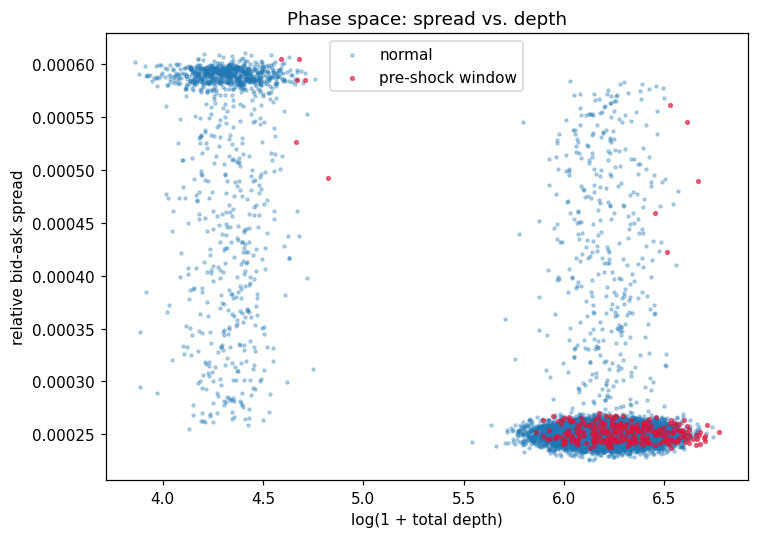

In [3]:
shock = merged["liquidity_shock_label"] == 1.0
log_depth = np.log1p(merged["total_depth"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(log_depth[~shock], merged.loc[~shock, "rolling_spread_20_rel"],
           s=4, alpha=0.3, label="normal")
ax.scatter(log_depth[shock], merged.loc[shock, "rolling_spread_20_rel"],
           s=6, alpha=0.6, color="crimson", label="pre-shock window")
ax.set_xlabel("log(1 + total depth)")
ax.set_ylabel("relative bid-ask spread")
ax.set_title("Phase space: spread vs. depth")
ax.legend()
fig.tight_layout()
plt.show()

## Fractional differencing: how much `d` do we actually need?

`FinancialTimeTransform.find_minimum_d` grid-searches `d` and reports, for each value:
- the ADF test statistic (more negative ⇒ more confidently stationary),
- correlation with the original (undifferenced) series, as a proxy for retained memory.

The goal is the **smallest `d`** that clears the stationarity bar — going all the way to `d=1` (plain differencing) is rarely necessary and destroys autocorrelation structure the LSTM could otherwise use.

In [4]:
transform = FinancialTimeTransform()
log_total_depth = np.log1p(cleaned["bid_size"] + cleaned["ask_size"]).rename("log_total_depth")

d_search = transform.find_minimum_d(log_total_depth, d_grid=np.linspace(0.0, 1.0, 11))
d_search

,d,adf_statistic,corr_with_original,is_stationary_95pct
0,0.0,-13.273050,1.000000,True
1,0.1,-12.294688,0.975450,True
2,0.2,-13.497339,0.903523,True
3,0.3,-14.936656,0.795132,True
4,0.4,-16.253436,0.667567,True
5,0.5,-17.010451,0.547604,True
6,0.6,-17.841693,0.445947,True
7,0.7,-18.745336,0.365215,True
8,0.8,-19.660708,0.305266,True
9,0.9,-20.617212,0.261542,True


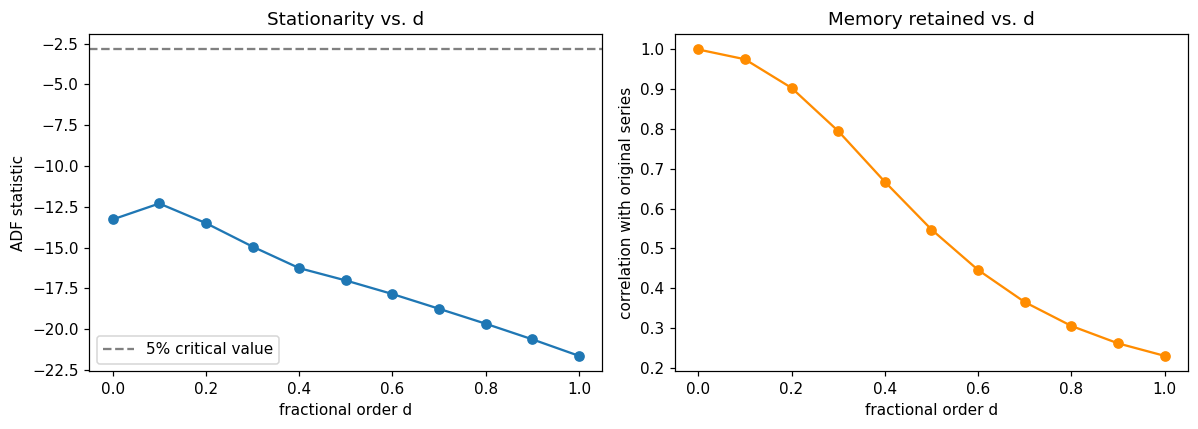

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(d_search["d"], d_search["adf_statistic"], marker="o")
ax1.axhline(-2.86, color="gray", linestyle="--", label="5% critical value")
ax1.set_xlabel("fractional order d")
ax1.set_ylabel("ADF statistic")
ax1.set_title("Stationarity vs. d")
ax1.legend()

ax2.plot(d_search["d"], d_search["corr_with_original"], marker="o", color="darkorange")
ax2.set_xlabel("fractional order d")
ax2.set_ylabel("correlation with original series")
ax2.set_title("Memory retained vs. d")

fig.tight_layout()
plt.show()

## Takeaways

- Pre-shock windows form a visually distinct region of the spread/depth phase space (low depth, elevated spread), which is exactly the kind of structure a sequence model can learn to anticipate a few steps ahead of time.
- The minimum-`d` search typically shows the ADF statistic crossing the stationarity threshold well before `d=1`, while correlation with the original series is still substantial — this is the practical justification for using fractional (rather than integer) differencing as a `FinancialTimeTransform` feature.
- Next step: feed the `merged` feature set through `DataPipeline.build_sequences` and `LiquidityAnomalyLSTM` (see `main.py train`) to go from EDA to a trained forecasting model.